<h1 style="text-align:center; color:salmon;">Kalshi World Cup — Exploratory Data Analysis</h1>

**Authors:** Henry Diep · James Zheng Cao

---

## What this notebook does

Loads the **minute-level price panel** produced by the collection notebook
(`data/backfill/{match_code}/…csv`, auto-unzipped if still a `.zip`), lets you
**pick a match** (`Cell 6`), and plots each contract's price path (match-winner and
total-goals) annotated with that match's **result, bookmaker odds, and team-strength
ratings** from `match_ratings.csv` (Elo + FIFA). A final section compares the
**market's pre-kickoff probabilities against the fundamentals** (Elo / FIFA gap).

---

## About the data

Each row of the **price panel** is one *contract* observed at one *timestamp* — i.e. the unit of observation is **[contract × time]**. Snapshots are recorded at a regular cadence (**about every 1–2 minutes**, see `collected_at_utc`, UTC).

Match-level context is joined from **`match_ratings.csv`** (a superset of `match_features.csv` that also carries the Elo and FIFA strength inputs produced by the collection notebook's Cell 7). If `match_ratings.csv` is absent, the notebook falls back to `match_features.csv`.

### Contract types

| `contract_type` | Kalshi series | Options per match | `yes_price` = probability that… |
|---|---|---|---|
| `match_winner` | `KXWCGAME` | **3 markets** — Team A wins · **Tie** (draw) · Team B wins. After the final whistle one team is the **Winner**, one the **Loser**. | …that outcome occurs (a team wins, or the match is drawn). |
| `goals_ou` | `KXWCTOTAL` | A **total-goals ladder** (lines `1`–`7`). | …the match ends with **at least *N* goals** (*over N − 0.5*). Higher lines → lower price. |

The **outcome is encoded in the ticker suffix**: e.g. `KXWCGAME-…-ARG` (Argentina wins), `…-TIE` (draw), `KXWCTOTAL-…-3` (≥ 3 total goals).

### 🧾 Column dictionary — price panel

| Column | Meaning |
|---|---|
| `collected_at_utc` | Snapshot time in **UTC** (~every 1–2 min) |
| `ticker` | Kalshi market id; **suffix = outcome** (team code, `TIE`, or goals line) |
| `contract_type` | `match_winner` or `goals_ou` |
| `yes_price` | Last traded **YES** price ($0–1) ≈ implied probability |
| `yes_bid` / `yes_ask` | Best **buy / sell** price for the YES side ($) |
| `no_bid` / `no_ask` | Best **buy / sell** price for the NO side ($) |
| `volume` | Contracts traded during the bar |
| `open_interest` | Contracts still outstanding |
| `end_period_ts` | Unix timestamp of the bar's end |
| `match_code` | Match key, e.g. `26JUL15ENGARG` = *15 Jul 2026, ENG vs ARG* |

### 🧾 Column dictionary — `match_ratings.csv` (one row per match)

*Result & odds (also in `match_features.csv`):*

| Column | Meaning |
|---|---|
| `home_team` / `away_team` | Team codes (home vs away) |
| `home_score` / `away_score` / `total_goals` | ⚽ Final score |
| `winner` | Winning team code, or `DRAW` |
| `result_type` | `FT` (full time) · `AET` (extra time) · `Pens` (shootout) |
| `went_to_extra_time` / `went_to_penalties` | Boolean flags |
| `minutes_played` | ⏱️ Duration proxy (final game clock) |
| `odds_home_ml` / `odds_draw_ml` / `odds_away_ml` | 🎲 Bookmaker **moneyline** odds |
| `odds_spread` / `odds_total` | Bookmaker spread & total-goals line |
| `attendance` / `venue` | Match context |
| `scorers` | Goal scorers (best-effort; may be empty) |

*Team-strength inputs (added by Cell 7):*

| Column | Meaning |
|---|---|
| `home_elo` / `away_elo` | World Football **Elo** rating of each side |
| `elo_diff` | `home_elo − away_elo` (the pairwise strength gap Δ) |
| `home_fifa_points` / `away_fifa_points` | Official **FIFA** ranking points |
| `fifa_diff` | `home_fifa_points − away_fifa_points` |

 
- The related tables `team_ratings.csv` (Elo + FIFA per team), `elo_ratings.csv`, and `fifa_ranking.csv` come from the collection notebook's Cell 7. The loaders here also read `fifa_ranking.csv` directly and canonicalize team codes (e.g. `USMNT → USA`).

---

## How to read the plots

- **Top panel** — the *match-winner* market (one line per team + `TIE`).
- **Bottom panel** — the *total-goals* over/under ladder.
- The **dashed vertical line** marks **kickoff**; sharp jumps after it are usually **goals** hitting the market.
- The **title** shows the final score / winner; the **grey footnote** (right) shows the bookmaker odds, and the **teal footnote** (left) shows the **Elo matchup, Δ Elo, Elo expected(home), and Δ FIFA points**.
- The final **market-vs-fundamentals** cell scatters each match's pre-kickoff, de-vigged **market P(home win)** against the **Elo / FIFA strength gap** (points colored by actual result), with the Elo expected-result reference curve.

---


# Cell 1 - Install dependencies

In [29]:
# import sys, subprocess

# Requirements:
# pip install pandas numpy matplotlib ipywidgets
# subprocess.check_call([sys.executable, "-m", "pip", "install",
#                        "pandas", "numpy", "matplotlib"]) 


## Cell 2 — Imports

In [30]:
import os
import re
import json
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Render plots inline when running inside Jupyter/Colab (no-op otherwise).
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

plt.rcParams["figure.dpi"] = 110
print("Ready.")

Ready.


## Cell 3 — Configuration & Auto-Unzip

In [31]:
# --- Configuration --------------------------------------------------------
# Root to search for price CSVs and match_features.csv. Point this at the
# folder you unzipped the collection output into (default: current dir).
ANALYSIS_ROOT = Path(".")

# Conventional locations (used only as hints; discovery is recursive below).
DATA_DIR = ANALYSIS_ROOT / "data"


def unzip_if_needed(root: Path = None) -> None:
    """Extract any .zip under root that contains backfill price CSVs.

    Args:
        root: Directory to scan (default ANALYSIS_ROOT).
    """
    root = Path(root or ANALYSIS_ROOT)
    for z in root.rglob("*.zip"):
        try:
            with zipfile.ZipFile(z) as zf:
                names = zf.namelist()
                if any(re.search(r"backfill_.+\.csv$", n) for n in names):
                    zf.extractall(z.parent)
                    print(f"Unzipped {z.name} -> {z.parent}")
        except Exception as e:  # noqa: BLE001
            print(f"[skip zip] {z}: {e}")


unzip_if_needed()

Unzipped data.zip -> .


## Cell 4 — Data Loaders

In [32]:
# --- Loaders --------------------------------------------------------------
def _code_from_path(p: Path) -> str:
    """Extract the match code from a backfill/labeled CSV filename."""
    m = re.search(r"(?:backfill)_(.+)\.csv$", p.name)
    return m.group(1) if m else None


def list_matches(root: Path = None) -> dict:
    """Discover available matches -> price CSV path (prefers labeled_ files).

    Args:
        root: Directory to search recursively (default ANALYSIS_ROOT).

    Returns:
        Ordered {match_code: Path}.
    """
    root = Path(root or ANALYSIS_ROOT)
    paths = {}
    for pattern in ["backfill_*.csv"]:  #backfill files
        
        for p in root.rglob(pattern):
            code = _code_from_path(p)
            if not code:
                continue
            if code not in paths or p.name.startswith("labeled_"):
                paths[code] = p
    return dict(sorted(paths.items()))


def load_prices(code: str) -> pd.DataFrame:
    """Load and time-sort the price panel for one match code."""
    matches = list_matches()
    if code not in matches:
        print("Match not found. Available:", list(matches))
        return None
    df = pd.read_csv(matches[code])
    df["t"] = pd.to_datetime(df["collected_at_utc"], utc=True)
    return df.sort_values("t").reset_index(drop=True)


# ESPN/collection code -> canonical Kalshi/FIFA 3-letter code. Fixes cases where
# the collection step normalized a team to a non-Kalshi label (e.g. USMNT->USA).
TEAM_ALIASES = {"USMNT": "USA"}


def _canon(code) -> str:
    """Canonicalize a team code to the Kalshi/FIFA convention."""
    return TEAM_ALIASES.get(str(code), str(code))


def load_features(code: str) -> pd.Series:
    """Load the per-match feature row (or None), canonicalizing team codes.

    Prefers match_ratings.csv (Cell 7 output) and falls back to
    match_features.csv. Remaps team codes via TEAM_ALIASES and, if Elo/FIFA
    columns are missing/blank, backfills them from team_ratings.csv using the
    canonical codes — so strength inputs survive a code mismatch in the CSV.
    """
    row = None
    for name in ["match_ratings.csv", "match_features.csv"]:
        csvs = list(Path(ANALYSIS_ROOT).rglob(name))
        if not csvs:
            continue
        df = pd.read_csv(csvs[0])
        r = df[df["match_code"].astype(str) == str(code)]
        if len(r):
            row = r.iloc[0].copy()
            break
    if row is None:
        return None
    for col in ["home_team", "away_team", "winner"]:
        if col in row and pd.notna(row[col]):
            row[col] = _canon(row[col])
    tr = load_team_ratings()
    if not tr.empty and "team_code" in tr.columns:
        maps = {c: tr.dropna(subset=["team_code"]).set_index("team_code")[c].to_dict()
                for c in ["elo", "fifa_points", "fifa_rank"] if c in tr.columns}
        for side in ["home", "away"]:
            tc = row.get(f"{side}_team")
            for c, m in maps.items():
                key = f"{side}_{c}"
                if (key not in row or pd.isna(row.get(key))) and tc in m:
                    row[key] = m[tc]
        if pd.notna(row.get("home_elo")) and pd.notna(row.get("away_elo")):
            row["elo_diff"] = row["home_elo"] - row["away_elo"]
        if pd.notna(row.get("home_fifa_points")) and pd.notna(row.get("away_fifa_points")):
            row["fifa_diff"] = row["home_fifa_points"] - row["away_fifa_points"]
    return row


def load_team_ratings() -> pd.DataFrame:
    """Combined per-team ratings: Elo (team_ratings.csv) + FIFA points
    (fifa_ranking.csv), merged on canonicalized team_code.

    Reads fifa_ranking.csv directly, so filling that file is enough for the EDA
    to pick up FIFA points — no need to re-run collection Cell 7.
    """
    def _find(name):
        csvs = list(Path(ANALYSIS_ROOT).rglob(name))
        return pd.read_csv(csvs[0]) if csvs else pd.DataFrame()

    tr = _find("team_ratings.csv")
    fifa = _find("fifa_ranking.csv")
    if tr.empty and fifa.empty:
        return pd.DataFrame()
    if not tr.empty and "team_code" in tr.columns:
        tr = tr.copy()
        tr["team_code"] = tr["team_code"].map(_canon)
    base = tr if not tr.empty else pd.DataFrame(columns=["team_code"])
    if not fifa.empty and "team_code" in fifa.columns:
        keep = [c for c in ["team_code", "fifa_points", "fifa_rank"]
                if c in fifa.columns]
        fifa = fifa[keep].copy()
        fifa["team_code"] = fifa["team_code"].map(_canon)
        fifa = (fifa.dropna(subset=["team_code"])
                    .drop_duplicates("team_code", keep="last"))
        base = base.drop(columns=[c for c in ["fifa_points", "fifa_rank"]
                                  if c in base.columns], errors="ignore")
        base = base.merge(fifa, on="team_code", how="outer")
    return base


print("Loaders ready. Matches found:", len(list_matches()))

Loaders ready. Matches found: 104


## Cell 5 — Plotting Function

In [33]:
# --- Plotting -------------------------------------------------------------
_TYPE_TITLES = {"match_winner": "Match winner (moneyline)",
                "goals_ou": "Total goals (over/under)"}


def _mid_price(df: pd.DataFrame) -> pd.Series:
    """Last-trade price where present, else the bid/ask midpoint."""
    mid = (df["yes_bid"] + df["yes_ask"]) / 2.0
    return df["yes_price"].where(df["yes_price"].notna(), mid)


def plot_match(code: str, price_field: str = "yes_price",
               save: bool = False) -> None:
    """Plot contract price paths for one match, annotated with its features.

    Args:
        code: Match code (e.g. "26JUL01BELSEN").
        price_field: "yes_price" (last trade, gap-filled) or "mid" (bid/ask mid).
        save: If True, also write a PNG to ./analysis_plots/.
    """
    prices = load_prices(code)
    if prices is None or prices.empty:
        print(f"No price data for {code}")
        return
    prices = prices.copy()
    prices["mid"] = _mid_price(prices)
    yv = "mid" if price_field == "mid" else "yes_price"

    feats = load_features(code)
    print(feats)
    types = [t for t in ["match_winner", "goals_ou"]
             if t in set(prices.get("contract_type", []))] or [None]

    fig, axes = plt.subplots(len(types), 1, figsize=(12, 4 * len(types)),
                             sharex=True)
    axes = np.atleast_1d(axes)
    for ax, ct in zip(axes, types):
        sub = prices if ct is None else prices[prices["contract_type"] == ct]
        for tk, g in sub.groupby("ticker"):
            g = g.sort_values("t")
            ax.plot(g["t"], g[yv].ffill(),
                    label=str(tk).split("-")[-1], linewidth=1.3)
        ax.set_ylabel("YES price ($)")
        ax.set_ylim(-0.02, 1.02)
        ax.set_title(_TYPE_TITLES.get(ct, "Contracts"), fontsize=10)
        ax.legend(loc="upper left", fontsize=8, ncol=5)
        ax.grid(alpha=0.3)
        # Mark kickoff (from match features) if available.
        if feats is not None and pd.notna(feats.get("kickoff_utc")):
            try:
                ax.axvline(pd.to_datetime(feats["kickoff_utc"], utc=True),
                           color="black", ls="--", lw=1, alpha=0.6)
                ax.text(pd.to_datetime(feats["kickoff_utc"], utc=True), 1.0,
                        " kickoff", fontsize=8, color="black", va="top")
            except Exception:
                pass

    # Title from result; footnote from odds.
    title = code
    if feats is not None:
        title = (f"{feats.get('home_team')} {feats.get('home_score')}-"
                 f"{feats.get('away_score')} {feats.get('away_team')}  "
                 f"({feats.get('result_type')})   winner: {feats.get('winner')}"
                 f"   [{code}]")
        odds = (f"Odds ({feats.get('odds_provider')}):  "
                f"H {feats.get('odds_home_ml')} / D {feats.get('odds_draw_ml')}"
                f" / A {feats.get('odds_away_ml')}   |   total "
                f"{feats.get('odds_total')}")
        fig.text(0.99, 0.005, odds, ha="right", fontsize=9, color="dimgray")
        # Fundamentals footnote (Elo + FIFA) from Cell 7 match_ratings.csv.
        try:
            ed, fd = feats.get("elo_diff"), feats.get("fifa_diff")
            he, ae = feats.get("home_elo"), feats.get("away_elo")
            parts = []
            if pd.notna(he) and pd.notna(ae) and pd.notna(ed):
                parts.append(f"Elo {feats.get('home_team')} {he:.0f} vs "
                             f"{feats.get('away_team')} {ae:.0f} (Δ{ed:+.0f})")
                parts.append(f"Elo exp(home)={1 / (1 + 10 ** (-ed / 400)):.2f}")
            if pd.notna(fd):
                parts.append(f"FIFA Δpts {fd:+.0f}")
            if parts:
                fig.text(0.01, 0.005, "   |   ".join(parts), ha="left",
                         fontsize=9, color="teal")
        except Exception:
            pass
    fig.suptitle(title, fontsize=13)
    axes[-1].set_xlabel("Time (UTC)")
    fig.tight_layout(rect=[0, 0.02, 1, 0.98])

    if save:
        out = Path("analysis_plots"); out.mkdir(exist_ok=True)
        fig.savefig(out / f"{code}.png", dpi=130, bbox_inches="tight")
        print("saved", out / f"{code}.png")
    plt.show()

## Cell 6 — Pick a Match

In [34]:
# --- Pick a match ---------------------------------------------------------
matches = list_matches()
print(f"{len(matches)} matches available:")
print(f"Here are the first 5:")
for c in list(matches):  # Show only the first 5 for brevity
    print("  ", c)

# Default selection = first match; change this or use the dropdown below.
SELECTED_MATCH = next(iter(matches), None)
SELECTED_MATCH = "26JUL07ARGEGY"  # Example: England vs Argentina, 15 July 2026
print("\nSelected:", SELECTED_MATCH)

104 matches available:
Here are the first 5:
   26JUL01BELSEN
   26JUL01ENGCOD
   26JUL01USABIH
   26JUL02ESPAUT
   26JUL02PORCRO
   26JUL02SUIDZA
   26JUL03ARGCPV
   26JUL03AUSEGY
   26JUL03COLGHA
   26JUL04CANMAR
   26JUL04PARFRA
   26JUL05BRANOR
   26JUL05MEXENG
   26JUL06PORESP
   26JUL06USABEL
   26JUL07ARGEGY
   26JUL07SUICOL
   26JUL09FRAMAR
   26JUL10ESPBEL
   26JUL11ARGSUI
   26JUL11NORENG
   26JUL14FRAESP
   26JUL15ENGARG
   26JUL18FRAENG
   26JUL19ESPARG
   26JUN11KORCZE
   26JUN11MEXRSA
   26JUN12CANBIH
   26JUN12USAPAR
   26JUN13BRAMAR
   26JUN13HTISCO
   26JUN13QATSUI
   26JUN14AUSTUR
   26JUN14CIVECU
   26JUN14GERCUW
   26JUN14NEDJPN
   26JUN14SWETUN
   26JUN15BELEGY
   26JUN15ESPCPV
   26JUN15IRINZL
   26JUN15KSAURU
   26JUN16ARGDZA
   26JUN16FRASEN
   26JUN16IRQNOR
   26JUN17AUTJOR
   26JUN17ENGCRO
   26JUN17GHAPAN
   26JUN17PORCOD
   26JUN17UZBCOL
   26JUN18CANQAT
   26JUN18CZERSA
   26JUN18MEXKOR
   26JUN18SUIBIH
   26JUN19BRAHTI
   26JUN19SCOMAR
   26JUN19TURPAR
   

In [35]:
match_df = load_prices(SELECTED_MATCH)
print(match_df.contract_type.unique())
print(match_df.collected_at_utc.unique()[0:5])

['goals_ou' 'match_winner']
['2026-07-07T12:33:00+00:00' '2026-07-07T12:36:00+00:00'
 '2026-07-07T12:37:00+00:00' '2026-07-07T12:41:00+00:00'
 '2026-07-07T12:43:00+00:00']


## Cell 7 — Plot the Selected Match

In [36]:
match_df

,match_code,ticker,collected_at_utc,end_period_ts,yes_bid,yes_ask,no_bid,no_ask,yes_price,volume,open_interest,contract_type,t
0,26JUL07ARGEGY,KXWCTOTAL-26JUL07ARGEGY-1,2026-07-07T12:33:00+00:00,1783427580,0.92,0.93,0.07,0.08,0.93,1605.03,87437.35,goals_ou,2026-07-07 12:33:00+00:00
1,26JUL07ARGEGY,KXWCTOTAL-26JUL07ARGEGY-1,2026-07-07T12:36:00+00:00,1783427760,0.92,0.93,0.07,0.08,0.93,26.75,87464.10,goals_ou,2026-07-07 12:36:00+00:00
2,26JUL07ARGEGY,KXWCTOTAL-26JUL07ARGEGY-1,2026-07-07T12:37:00+00:00,1783427820,0.92,0.93,0.07,0.08,0.93,107.52,87571.62,goals_ou,2026-07-07 12:37:00+00:00
3,26JUL07ARGEGY,KXWCTOTAL-26JUL07ARGEGY-1,2026-07-07T12:41:00+00:00,1783428060,0.92,0.93,0.07,0.08,0.93,151.16,87722.78,goals_ou,2026-07-07 12:41:00+00:00
4,26JUL07ARGEGY,KXWCTOTAL-26JUL07ARGEGY-1,2026-07-07T12:43:00+00:00,1783428180,0.92,0.93,0.07,0.08,0.93,26.75,87749.53,goals_ou,2026-07-07 12:43:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,26JUL07ARGEGY,KXWCGAME-26JUL07ARGEGY-EGY,2026-07-07T18:04:00+00:00,1783447440,0.00,0.01,0.99,1.00,0.01,11221.51,4257709.53,match_winner,2026-07-07 18:04:00+00:00
2662,26JUL07ARGEGY,KXWCTOTAL-26JUL07ARGEGY-7,2026-07-07T18:04:00+00:00,1783447440,0.00,0.01,0.99,1.00,NaN,0.00,40121.63,goals_ou,2026-07-07 18:04:00+00:00
2663,26JUL07ARGEGY,KXWCTOTAL-26JUL07ARGEGY-6,2026-07-07T18:05:00+00:00,1783447500,0.02,0.03,0.97,0.98,0.03,105740.07,891198.43,goals_ou,2026-07-07 18:05:00+00:00
2664,26JUL07ARGEGY,KXWCTOTAL-26JUL07ARGEGY-5,2026-07-07T18:05:00+00:00,1783447500,0.99,1.00,0.00,0.01,0.99,1127.97,723983.43,goals_ou,2026-07-07 18:05:00+00:00


In [37]:
# --- Plot (interactive dropdown if ipywidgets is available) ---------------
try:
    from ipywidgets import interact # type: ignore
    interact(lambda match=list(matches): plot_match(match),
             match=list(matches))
except Exception:
    if SELECTED_MATCH:
        plot_match(SELECTED_MATCH)
    else:
        print("No matches found. Check ANALYSIS_ROOT / that the price folder "
                "is unzipped.")

interactive(children=(Dropdown(description='match', options=('26JUL01BELSEN', '26JUL01ENGCOD', '26JUL01USABIH'…

## Cell 8 — Numeric Summary

In [38]:
# --- Quick numeric summary for the selected match -------------------------
def match_summary(code: str) -> pd.DataFrame:
    """Per-contract summary (obs, coverage, last price, price range)."""
    df = load_prices(code)
    if df is None or df.empty:
        print(f"No data for {code}")
        return pd.DataFrame()
    df = df.copy()
    df["mid"] = _mid_price(df)
    rows = []
    for tk, g in df.groupby("ticker"):
        g = g.sort_values("t")
        rows.append({
            "ticker": tk,
            "type": g["contract_type"].iloc[0] if "contract_type" in g else None,
            "n_minutes": len(g),
            "start_utc": g["t"].min(),
            "end_utc": g["t"].max(),
            "last_yes_price": g["yes_price"].ffill().iloc[-1],
            "min_mid": round(float(g["mid"].min()), 3),
            "max_mid": round(float(g["mid"].max()), 3),
            "total_volume": round(float(g["volume"].sum()), 1),
        })
    out = pd.DataFrame(rows).sort_values("total_volume", ascending=False)
    return out.reset_index(drop=True)


feats = load_features(SELECTED_MATCH) if SELECTED_MATCH else None
if feats is not None:
    print("Match features:")
    print(feats.to_string())
    print()
match_summary(SELECTED_MATCH) if SELECTED_MATCH else pd.DataFrame()

Match features:
match_code                    26JUL07ARGEGY
espn_event_id                        760509
kickoff_utc               2026-07-07T16:00Z
home_team                               ARG
away_team                               EGY
home_score                                3
away_score                                2
total_goals                               5
winner                                  ARG
result_type                              FT
went_to_extra_time                    False
went_to_penalties                     False
pens_home                               NaN
pens_away                               NaN
final_clock                         90'+11'
minutes_played                          101
attendance                            68239
venue                 Mercedes-Benz Stadium
n_odds_providers                          1
odds_provider                    DraftKings
odds_home_ml                           -310
odds_draw_ml                          390.0
odds_away_ml    

,ticker,type,n_minutes,start_utc,end_utc,last_yes_price,min_mid,max_mid,total_volume
0,KXWCGAME-26JUL07ARGEGY-ARG,match_winner,300,2026-07-07 13:05:00+00:00,2026-07-07 18:04:00+00:00,0.98,0.020,0.990,12467327.5
1,KXWCGAME-26JUL07ARGEGY-EGY,match_winner,300,2026-07-07 13:05:00+00:00,2026-07-07 18:04:00+00:00,0.01,0.010,0.860,9641207.5
2,KXWCGAME-26JUL07ARGEGY-TIE,match_winner,300,2026-07-07 13:05:00+00:00,2026-07-07 18:04:00+00:00,0.02,0.020,0.740,9386274.7
3,KXWCTOTAL-26JUL07ARGEGY-3,goals_ou,300,2026-07-07 12:52:00+00:00,2026-07-07 17:51:00+00:00,0.99,0.310,0.990,4109234.7
4,KXWCTOTAL-26JUL07ARGEGY-2,goals_ou,299,2026-07-07 12:46:00+00:00,2026-07-07 17:46:00+00:00,0.99,0.660,0.990,1888206.4
5,KXWCTOTAL-26JUL07ARGEGY-4,goals_ou,300,2026-07-07 12:56:00+00:00,2026-07-07 17:55:00+00:00,0.99,0.110,0.990,1678532.8
6,KXWCTOTAL-26JUL07ARGEGY-6,goals_ou,256,2026-07-07 13:10:00+00:00,2026-07-07 18:05:00+00:00,0.03,0.005,0.190,1652851.9
7,KXWCTOTAL-26JUL07ARGEGY-5,goals_ou,282,2026-07-07 13:06:00+00:00,2026-07-07 18:05:00+00:00,0.99,0.020,0.990,1599005.7
8,KXWCTOTAL-26JUL07ARGEGY-1,goals_ou,245,2026-07-07 12:33:00+00:00,2026-07-07 17:30:00+00:00,0.99,0.900,0.995,321970.2
9,KXWCTOTAL-26JUL07ARGEGY-7,goals_ou,84,2026-07-07 16:22:00+00:00,2026-07-07 18:05:00+00:00,0.01,0.005,0.180,47020.8


## Cell 9 — Market vs Fundamentals (uses Cell 7 Elo / FIFA)

For every match, take the **de-vigged pre-kickoff market probability** of a home
win from the three `KXWCGAME` contracts and compare it to the fundamentals
strength gap (`elo_diff`, `fifa_diff`) produced by **Cell 7**. This is the
central "does the market agree with the ratings?" view.

In [39]:
# --- Pre-kickoff market probabilities per match ---------------------------
def _last_prekickoff(df: pd.DataFrame, kickoff) -> pd.DataFrame:
    """Rows at the latest timestamp at or before kickoff (else the last row)."""
    if kickoff is not None and pd.notna(kickoff):
        pre = df[df["t"] <= kickoff]
        use = pre if not pre.empty else df
    else:
        use = df
    return use[use["t"] == use["t"].max()]


def prekickoff_market_probs(code: str) -> dict:
    """De-vigged pre-kickoff P(home/draw/away win) + fundamentals for one match."""
    prices, feats = load_prices(code), load_features(code)
    if prices is None or feats is None:
        return None
    mw = prices[prices["contract_type"] == "match_winner"].copy()
    if mw.empty:
        return None
    mw["mid"] = _mid_price(mw)
    kickoff = pd.to_datetime(feats.get("kickoff_utc"), utc=True, errors="coerce")
    snap = _last_prekickoff(mw, kickoff)
    mids = {str(r["ticker"]).split("-")[-1]: r["mid"] for _, r in snap.iterrows()}
    home, away = str(feats.get("home_team")), str(feats.get("away_team"))
    ph, pa, pt = mids.get(home), mids.get(away), mids.get("TIE")
    vals = [x for x in (ph, pa, pt) if x is not None and not pd.isna(x)]
    tot = sum(vals)
    if not tot:
        return None
    nz = lambda x: (x / tot) if (x is not None and not pd.isna(x)) else None
    return {
        "match_code": code, "home_team": home, "away_team": away,
        "p_home_mkt": nz(ph), "p_draw_mkt": nz(pt), "p_away_mkt": nz(pa),
        "elo_diff": feats.get("elo_diff"), "fifa_diff": feats.get("fifa_diff"),
        "home_win": 1 if str(feats.get("winner")) == home else 0,
    }


mvf = pd.DataFrame(
    [r for r in (prekickoff_market_probs(c) for c in list_matches()) if r])
print(f"Built market-vs-fundamentals table for {len(mvf)} matches.")
mvf.head(10)

Built market-vs-fundamentals table for 94 matches.


,match_code,home_team,away_team,p_home_mkt,p_draw_mkt,p_away_mkt,elo_diff,fifa_diff,home_win
0,26JUL01BELSEN,BEL,SEN,0.495146,0.281553,0.223301,132.0,124.93,1
1,26JUL01ENGCOD,ENG,COD,0.754902,0.186275,0.058824,421.0,427.35,1
2,26JUL01USABIH,USA,BIH,0.715686,0.186275,0.098039,NaN,281.40,1
3,26JUL02ESPAUT,ESP,AUT,0.722772,0.188119,0.089109,438.0,397.06,1
4,26JUL02PORCRO,POR,CRO,0.572816,0.262136,0.165049,113.0,64.80,1
5,26JUL03ARGCPV,ARG,CPV,0.852941,0.107843,0.039216,554.0,567.40,1
6,26JUL03AUSEGY,AUS,EGY,0.262136,0.349515,0.388350,53.0,-15.53,0
7,26JUL03COLGHA,COL,GHA,0.666667,0.225490,0.107843,433.0,352.89,1
8,26JUL04CANMAR,CAN,MAR,0.178218,0.287129,0.534653,-172.0,-232.65,0
9,26JUL04PARFRA,PAR,FRA,0.049505,0.138614,0.811881,-256.0,-406.49,0


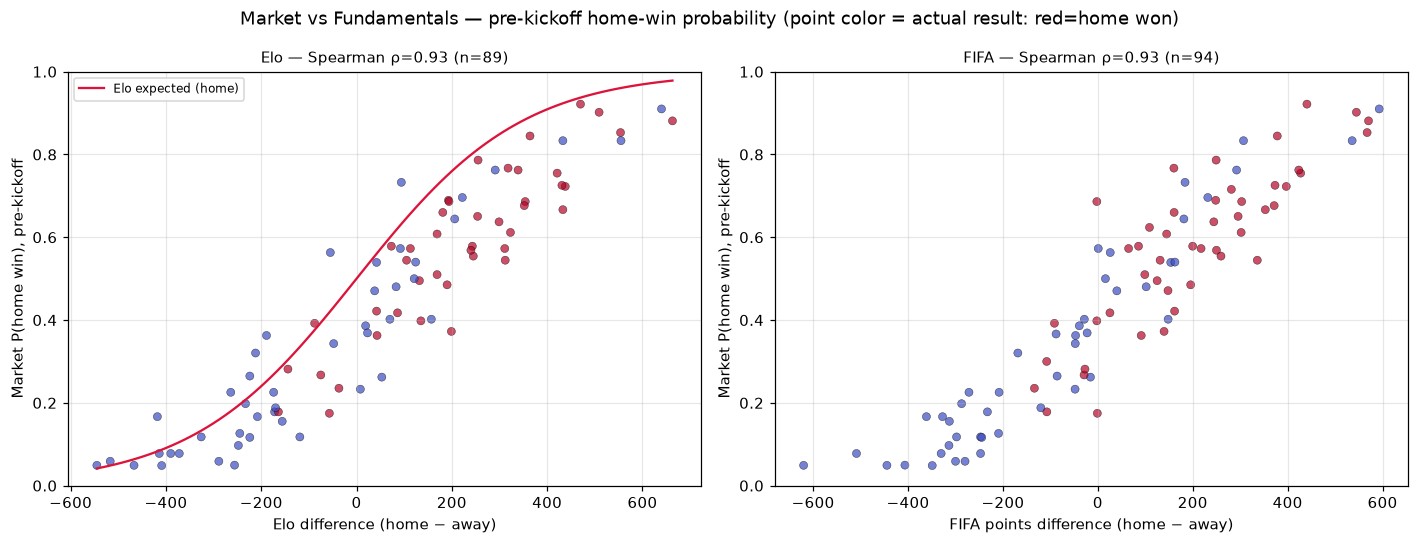

In [40]:
# --- Scatter: market P(home win) vs Elo / FIFA strength gap ----------------
if mvf.empty:
    print("No matches with market probabilities to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    panels = [("elo_diff", "Elo difference (home − away)"),
              ("fifa_diff", "FIFA points difference (home − away)")]
    for ax, (xcol, xlabel) in zip(axes, panels):
        sub = mvf.dropna(subset=[xcol, "p_home_mkt"])
        ax.scatter(sub[xcol], sub["p_home_mkt"], s=28, alpha=0.7,
                   c=sub["home_win"], cmap="coolwarm", edgecolor="k", linewidth=0.3)
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Market P(home win), pre-kickoff")
        ax.set_ylim(0, 1)
        ax.grid(alpha=0.3)
        title = xlabel.split(" ")[0]
        if len(sub) >= 3:
            rho = sub[xcol].corr(sub["p_home_mkt"], method="spearman")
            title += f" — Spearman ρ={rho:.2f} (n={len(sub)})"
        ax.set_title(title, fontsize=10)
    # Elo expected-result reference curve on the Elo panel.
    e = mvf["elo_diff"].dropna()
    if not e.empty:
        xs = np.linspace(e.min(), e.max(), 100)
        axes[0].plot(xs, 1 / (1 + 10 ** (-xs / 400)), color="crimson", lw=1.5,
                     label="Elo expected (home)")
        axes[0].legend(fontsize=8)
    fig.suptitle("Market vs Fundamentals — pre-kickoff home-win probability "
                 "(point color = actual result: red=home won)", fontsize=12)
    fig.tight_layout()
    plt.show()